In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("prof_components_extracted")
firms_plot5 = ["EQNR.OL", "AKRBP.OL", "NHY.OL"]

# ---------- Load ALL firm CSVs into one panel ----------
MIN_YEAR = 2005
MAX_YEAR = 2024

rows = []
bad_files = []

for fp in sorted(DATA_DIR.glob("*.csv")):
    firm = fp.stem
    df = pd.read_csv(fp)

    if "Year" not in df.columns:
        bad_files.append(fp.name)
        continue

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"]).copy()
    df["Year"] = df["Year"].astype(int)
    df = df[(df["Year"] >= MIN_YEAR) & (df["Year"] <= MAX_YEAR)].sort_values("Year")

    # fallback if needed
    if "firm" not in df.columns:
        df["firm"] = firm
    if "Ticker" not in df.columns:
        df["Ticker"] = firm

    rows.append(df)

if not rows:
    raise ValueError("No valid CSV files were loaded into panel.")

panel = pd.concat(rows, ignore_index=True)

panel["BE"] = pd.to_numeric(panel["BE"], errors="coerce")
panel["MIB"] = pd.to_numeric(panel["MIB"], errors="coerce")
panel["DENOM"] = panel["BE"] + panel["MIB"]

panel = panel.replace([np.inf, -np.inf], np.nan)
panel = panel.dropna(subset=["DENOM"]).copy()

# keep only positive denominators
panel = panel[panel["DENOM"] > 0].copy()

print(f"Panel after filter: {len(panel):,} rows, {panel['Ticker'].nunique():,} firms.")
print("Columns in panel:", panel.columns.tolist())

if bad_files:
    print("\nFiles skipped because Year column was missing:")
    for f in bad_files:
        print("-", f)

# Ensure PROF exists
if "PROF" not in panel.columns:
    raise ValueError("Column 'PROF' not found. Make sure you've computed PROF and saved it in each CSV.")

Panel after filter: 9,590 rows, 634 firms.
Columns in panel: ['Year', 'Ticker', 'CompanyName', 'Industry', 'Sector', 'REVT', 'COGS', 'XSGA_COMPONENTS', 'XRD', 'XINT', 'BE', 'MIB', 'PROF', 'firm', 'DENOM']


In [16]:
# List unique industries in the current `panel` DataFrame (and counts)

if "Industry" not in panel.columns:
    raise ValueError("panel has no 'Industry' column. Rebuild panel from CSVs that include Industry/Sector.")

industry_counts = (
    panel.dropna(subset=["Industry"])
         .assign(Industry=lambda d: d["Industry"].astype(str).str.strip())
         .query("Industry != ''")
         .groupby("Industry")["firm"]
         .nunique()
         .sort_values(ascending=False)
)

print(f"Number of unique industries: {industry_counts.shape[0]}\n")
print(industry_counts.to_string())

Number of unique industries: 47

Industry
Machinery, Tools, Heavy Vehicles, Trains & Ships    64
Software & IT Services                              56
Real Estate Operations                              51
Professional & Commercial Services                  31
Healthcare Equipment & Supplies                     30
Construction & Engineering                          28
Food & Tobacco                                      26
Biotechnology & Medical Research                    25
Pharmaceuticals                                     24
Oil & Gas Related Equipment and Services            23
Freight & Logistics Services                        22
Metals & Mining                                     19
Oil & Gas                                           16
Hotels & Entertainment Services                     15
Chemicals                                           13
Media & Publishing                                  13
Homebuilding & Construction Supplies                12
Specialty Retailers    

In [17]:
from IPython.display import HTML, display

financial_firms = (
    panel.loc[
        panel["Sector"].astype(str).str.strip().str.lower() == "financials",
        ["Ticker", "CompanyName", "Industry", "Sector"]
    ]
    .drop_duplicates()
    .copy()
)

# Extract exchange suffix from ticker, e.g. EQNR.OL -> OL
financial_firms["Exchange"] = financial_firms["Ticker"].astype(str).str.extract(r"\.([A-Za-z]+)$")[0]
financial_firms["Exchange"] = financial_firms["Exchange"].fillna("NO_SUFFIX")

# Sort by exchange first, then ticker
financial_firms = (
    financial_firms
    .sort_values(["Exchange", "Ticker"])
    .reset_index(drop=True)
)

print(f"Number of financial firms: {len(financial_firms)}")

html_table = financial_firms.to_html(index=False, escape=False)
html_scroll = f"""
<div style="max-height: 500px; overflow-y: auto; border: 1px solid #ccc;">
    {html_table}
</div>
"""

display(HTML(html_scroll))

Number of financial firms: 0


Ticker,CompanyName,Industry,Sector,Exchange


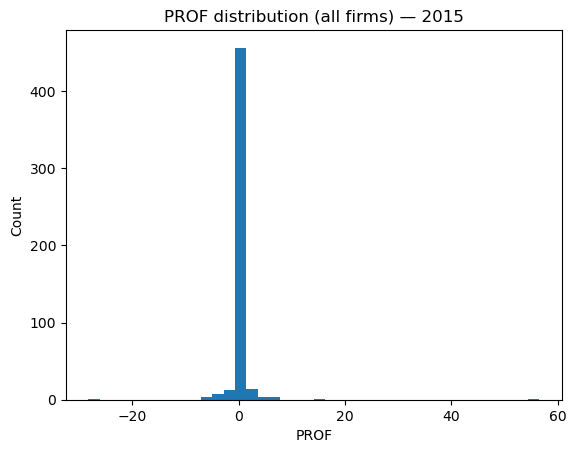

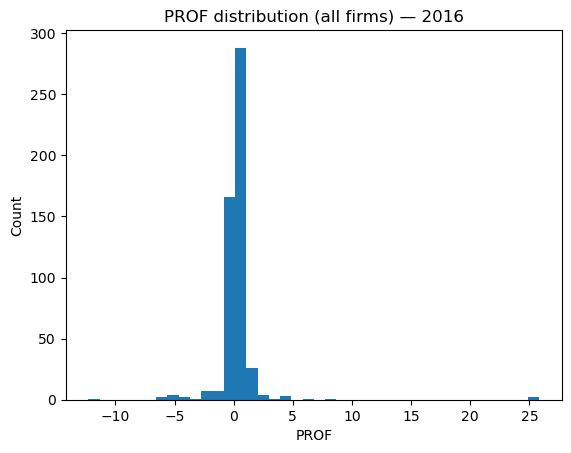

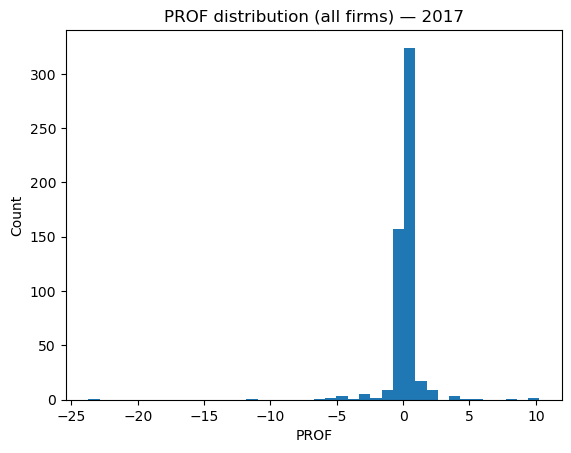

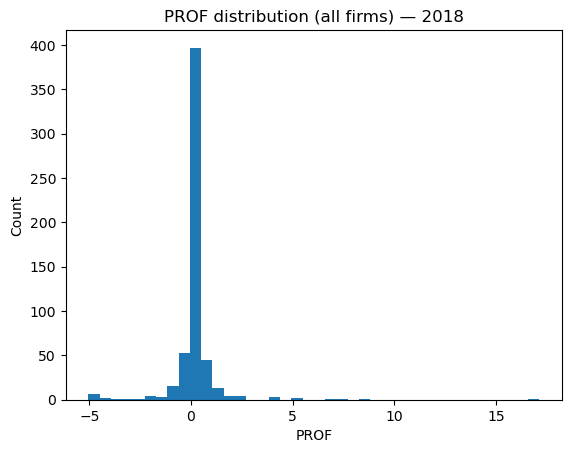

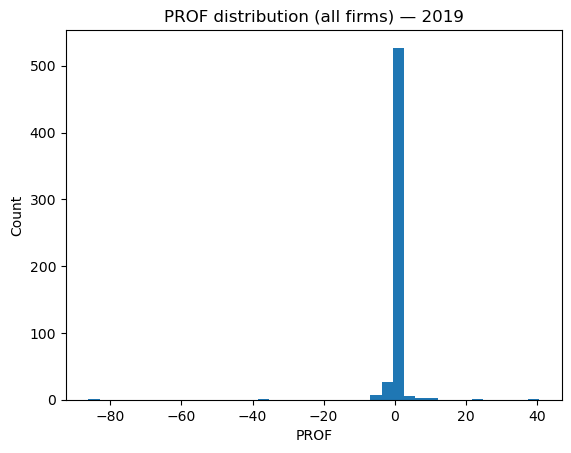

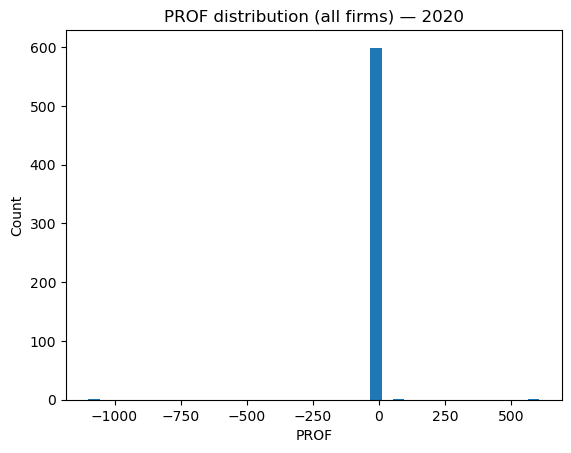

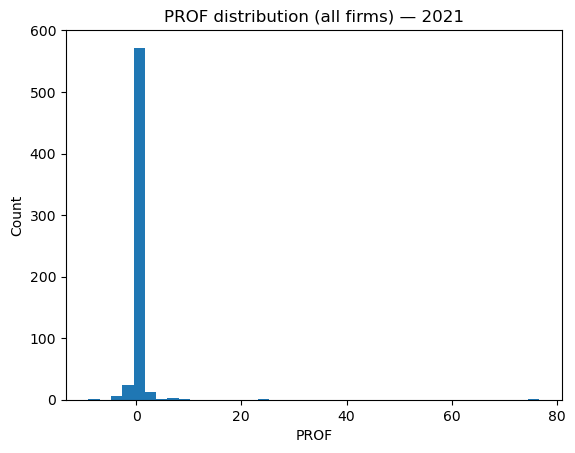

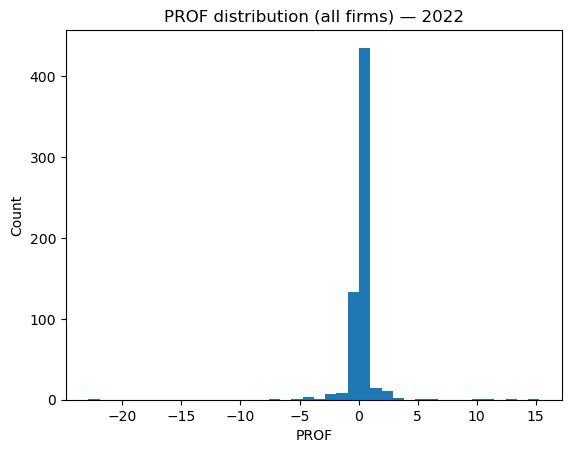

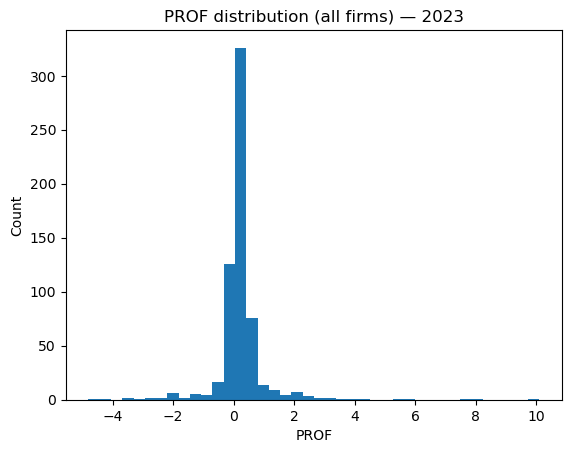

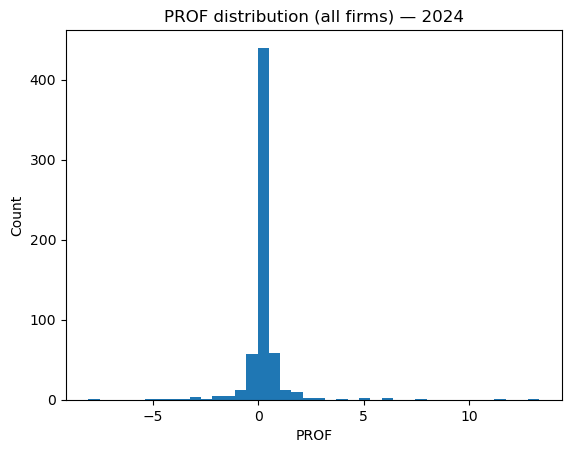

In [18]:

# ---------- Plot 1: PROF distribution each year (ALL firms) ----------
years = sorted(panel["Year"].unique())
years_to_plot = years[-10:] if len(years) > 10 else years  # last 10 years if many

for y in years_to_plot:
    vals = panel.loc[panel["Year"] == y, "PROF"].replace([np.inf, -np.inf], np.nan).dropna()
    plt.figure()
    plt.hist(vals, bins=40)
    plt.title(f"PROF distribution (all firms) — {y}")
    plt.xlabel("PROF")
    plt.ylabel("Count")
    plt.show()


/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_50952/3868926889.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mom = panel.groupby("Year").apply(moments).reset_index()


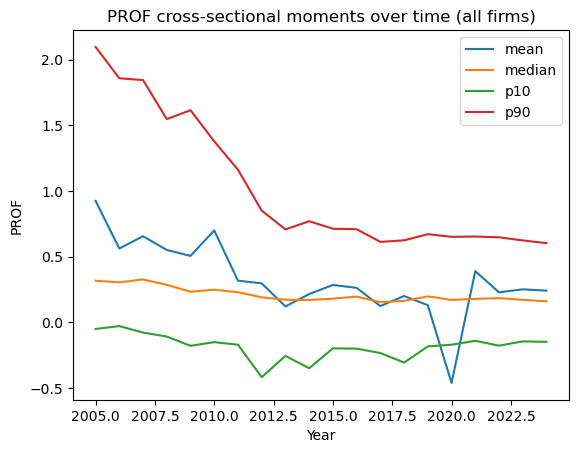

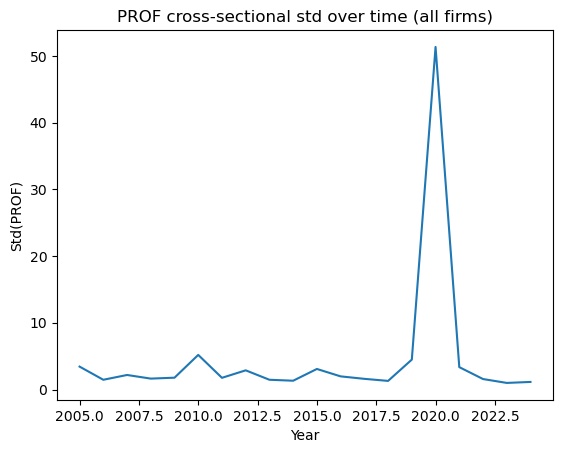

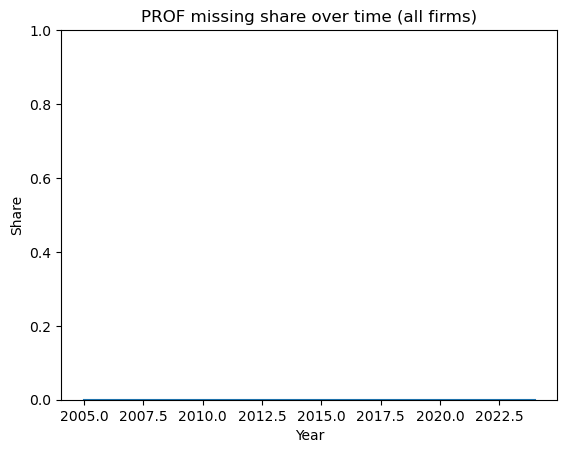

In [19]:

# ---------- Plot 2: Cross-sectional moments over time (ALL firms) ----------
def moments(g):
    s = g["PROF"].replace([np.inf, -np.inf], np.nan)
    return pd.Series({
        "mean": s.mean(),
        "median": s.median(),
        "p10": s.quantile(0.10),
        "p90": s.quantile(0.90),
        "std": s.std(),
        "n": s.notna().sum(),
        "nan_share": 1 - s.notna().mean(),
    })

mom = panel.groupby("Year").apply(moments).reset_index()

plt.figure()
plt.plot(mom["Year"], mom["mean"], label="mean")
plt.plot(mom["Year"], mom["median"], label="median")
plt.plot(mom["Year"], mom["p10"], label="p10")
plt.plot(mom["Year"], mom["p90"], label="p90")
plt.title("PROF cross-sectional moments over time (all firms)")
plt.xlabel("Year")
plt.ylabel("PROF")
plt.legend()
plt.show()

plt.figure()
plt.plot(mom["Year"], mom["std"])
plt.title("PROF cross-sectional std over time (all firms)")
plt.xlabel("Year")
plt.ylabel("Std(PROF)")
plt.show()

plt.figure()
plt.plot(mom["Year"], mom["nan_share"])
plt.title("PROF missing share over time (all firms)")
plt.xlabel("Year")
plt.ylabel("Share")
plt.ylim(0, 1)
plt.show()


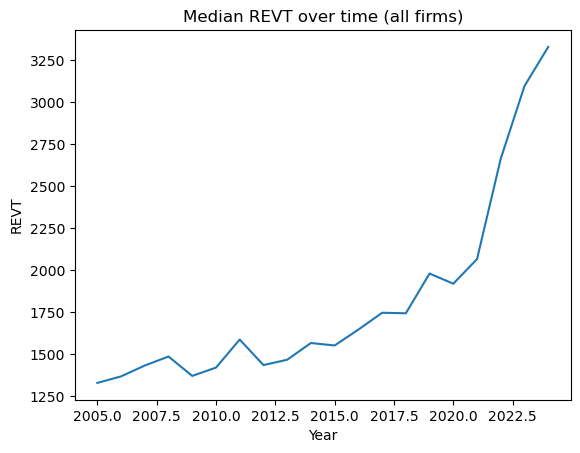

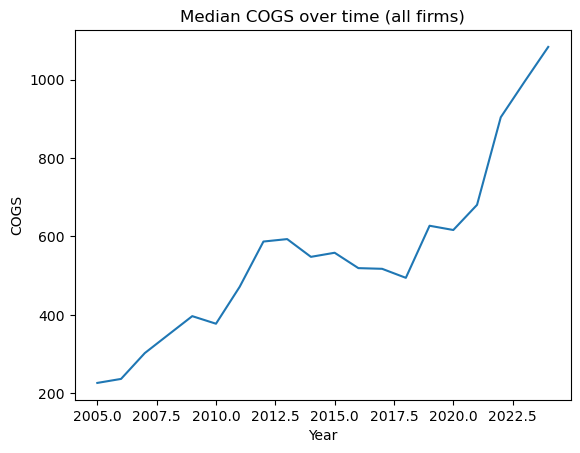

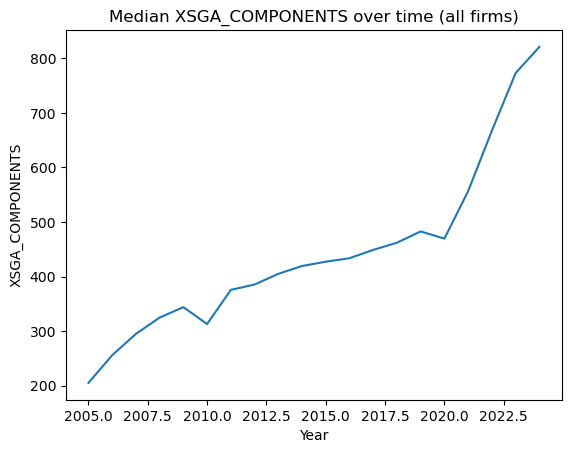

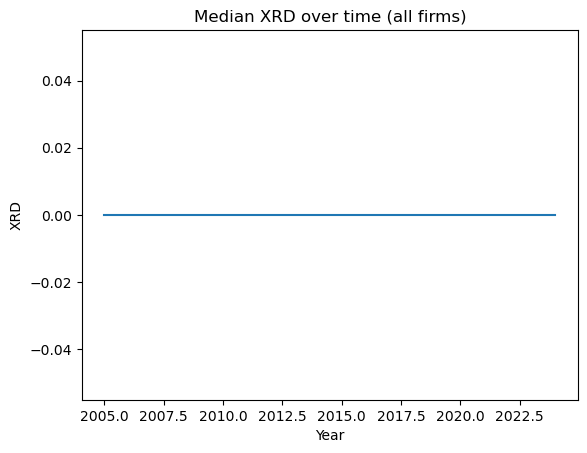

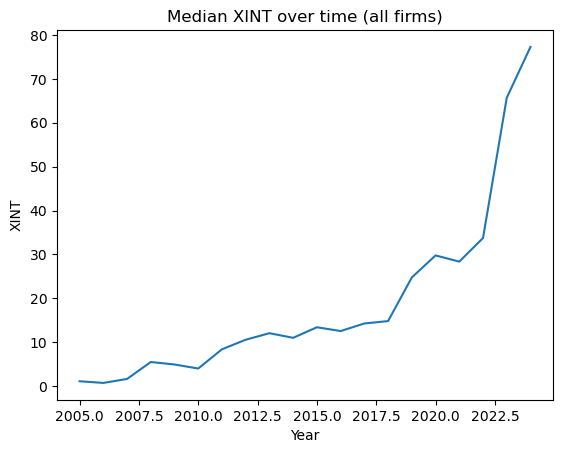

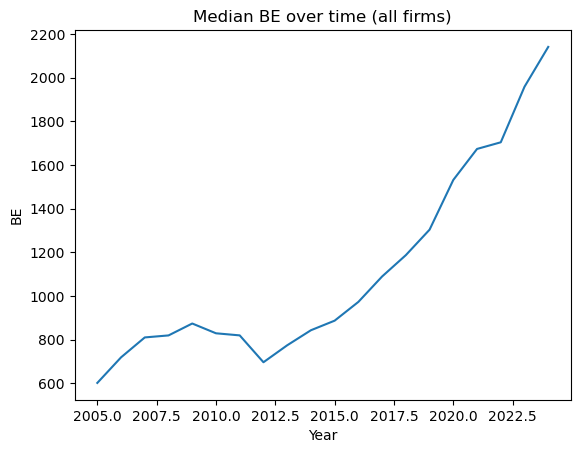

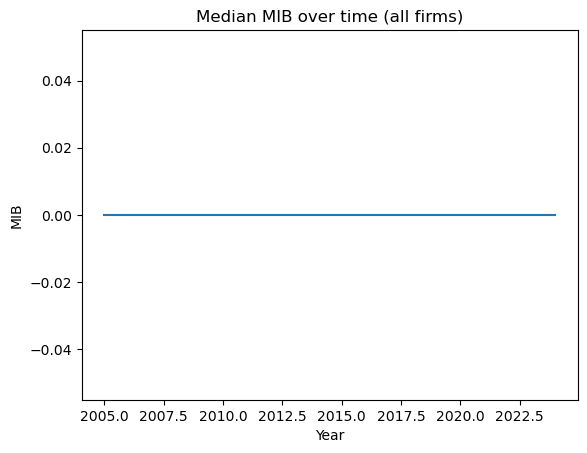

In [20]:

# ---------- Plot 3: Component diagnostics over time (ALL firms, medians) ----------
components = ["REVT", "COGS", "XSGA_COMPONENTS", "XRD", "XINT", "BE", "MIB"]
missing_components = [c for c in components if c not in panel.columns]
if missing_components:
    raise ValueError(f"Missing component columns in panel: {missing_components}")

comp_median = panel.groupby("Year")[components].median(numeric_only=True).reset_index()

for c in components:
    plt.figure()
    plt.plot(comp_median["Year"], comp_median[c])
    plt.title(f"Median {c} over time (all firms)")
    plt.xlabel("Year")
    plt.ylabel(c)
    plt.show()


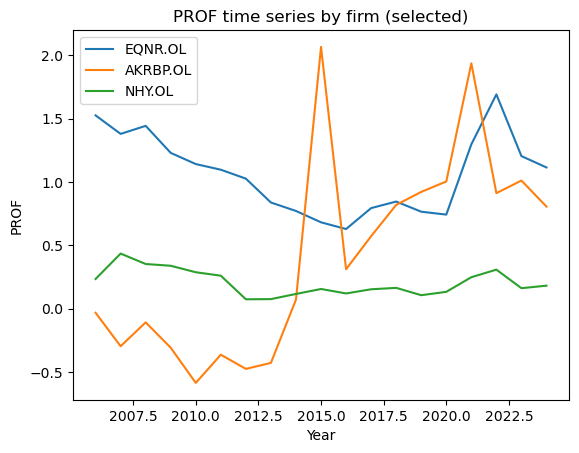

In [21]:

# ---------- Plot 5: Firm-level PROF time series (ONLY specified firms) ----------
plt.figure()
for f in firms_plot5:
    d = panel[panel["firm"] == f].sort_values("Year")
    if d.empty:
        print(f"[warn] No data found for {f}")
        continue
    plt.plot(d["Year"], d["PROF"], label=f)
plt.title("PROF time series by firm (selected)")
plt.xlabel("Year")
plt.ylabel("PROF")
plt.legend()
plt.show()

In [22]:
top5_one_row_per_year = (
    panel.assign(PROF=pd.to_numeric(panel["PROF"], errors="coerce"))
         .replace([np.inf, -np.inf], np.nan)
         .dropna(subset=["PROF"])
         .sort_values(["Year", "PROF"], ascending=[True, False])
         .groupby("Year", as_index=False)
         .head(5)
         .groupby("Year")
         .apply(lambda g: pd.Series({
             "top5_firms": ", ".join(g["firm"].tolist()),
             "top5_PROF": ", ".join([f"{x:.4f}" for x in g["PROF"].tolist()])
         }))
         .reset_index()
         .sort_values("Year")
         .reset_index(drop=True)
)

display(top5_one_row_per_year)

/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_50952/1156369912.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  panel.assign(PROF=pd.to_numeric(panel["PROF"], errors="coerce"))


,Year,top5_firms,top5_PROF
0,2005,"AQ.ST, ATEA.OL, LOOMIS.ST, NAS.OL, STWK.ST","48.8671, 22.4555, 11.5817, 10.9941, 9.1360"
1,2006,"NAS.OL, BILIa.ST, PROFb.ST, AKAST.OL, DUNI.ST","10.7473, 7.0427, 6.2680, 6.1823, 5.9667"
2,2007,"ARCHA.OL, BILIa.ST, AKAST.OL, NCCb.ST, NAS.OL","29.5115, 9.3255, 7.9466, 7.9135, 6.7377"
3,2008,"MOWI.OL, BILIa.ST, ARCHA.OL, NCCb.ST, IOX.OL","11.9971, 9.7008, 8.9575, 8.3611, 7.7158"
4,2009,"NELLY.ST, WALLb.ST, BILIa.ST, SOSI1.HE, NCCb.ST","17.5138, 10.9412, 8.5364, 8.0000, 7.2137"
5,2010,"AFG.OL, PREVb.ST, AXFO.ST, WALLb.ST, BILIa.ST","86.6818, 39.3158, 9.9455, 9.1932, 8.0149"
6,2011,"PREVb.ST, BILIa.ST, AXFO.ST, VERK.HE, NAS.OL","20.5427, 9.8674, 8.2893, 5.6176, 4.3306"
7,2012,"BWLPG.OL, VERK.HE, LEHTO.HE, AFG.OL, PREVb.ST","52.9398, 7.6974, 7.1407, 6.8339, 5.6244"
8,2013,"AFG.OL, ATEA.OL, ORIOLA.HE, NAS.OL, VERK.HE","9.0473, 4.9272, 4.5771, 4.2561, 4.1347"
9,2014,"ORIOLA.HE, CONSTI.HE, PREVb.ST, NAS.OL, AFG.OL","11.1796, 7.9214, 7.7214, 6.8540, 5.6912"


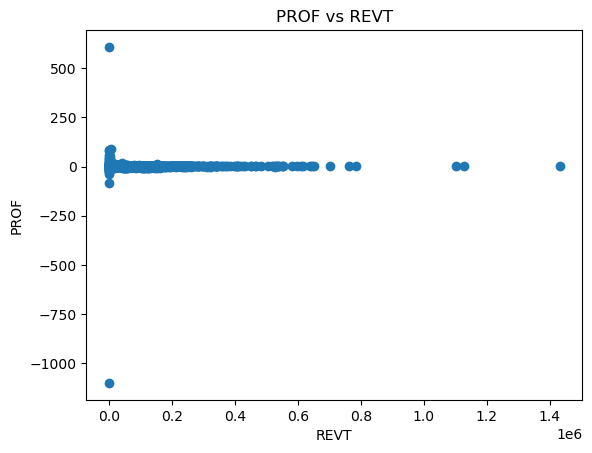

In [23]:
# Scatterplot: PROF (y) vs REVT (x), using existing `panel`
x = pd.to_numeric(panel["REVT"], errors="coerce")
y = pd.to_numeric(panel["PROF"], errors="coerce")

mask = np.isfinite(x) & np.isfinite(y)
plt.figure()
plt.scatter(x[mask], y[mask])
plt.title("PROF vs REVT")
plt.xlabel("REVT")
plt.ylabel("PROF")
plt.show()

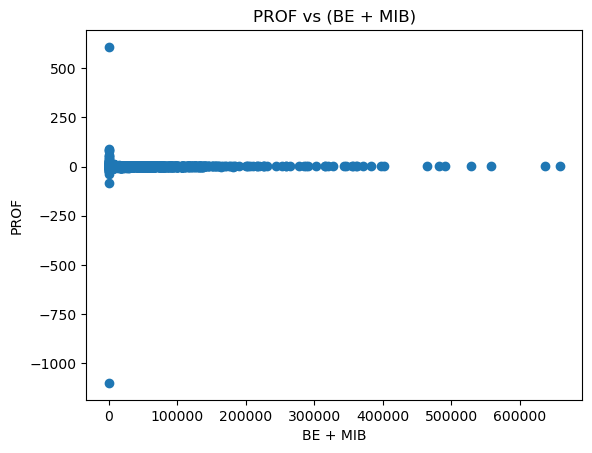

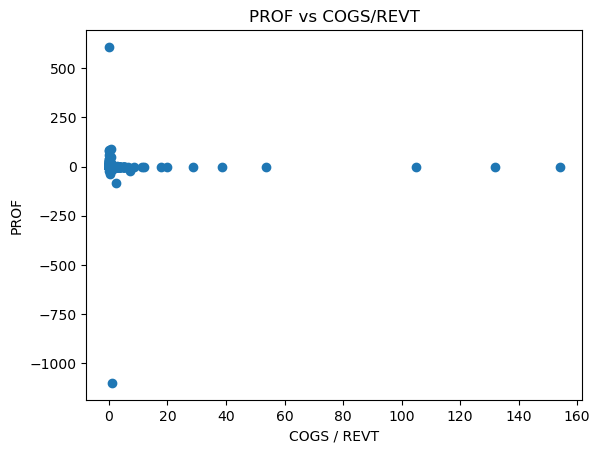

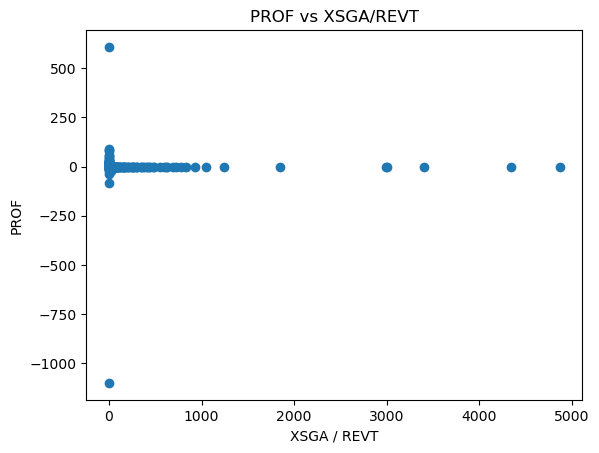

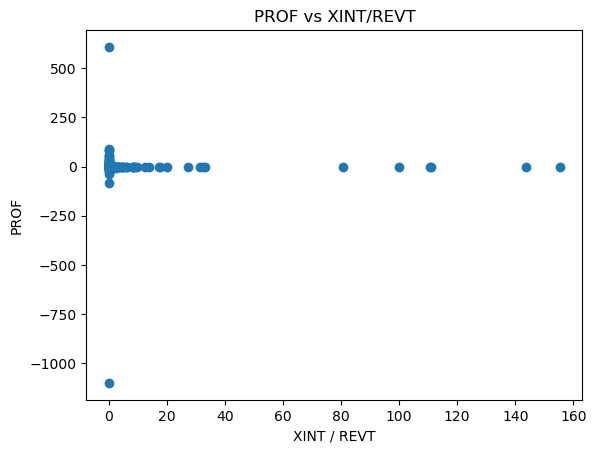

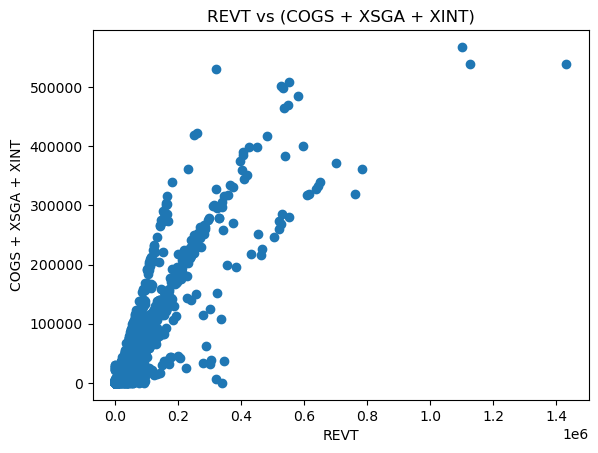

In [24]:
def scatter(x, y, title, xlabel, ylabel):
    x = pd.to_numeric(x, errors="coerce")
    y = pd.to_numeric(y, errors="coerce")
    mask = np.isfinite(x) & np.isfinite(y)
    plt.figure()
    plt.scatter(x[mask], y[mask])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# 1) PROF vs denominator
denom = pd.to_numeric(panel["BE"], errors="coerce") + pd.to_numeric(panel["MIB"], errors="coerce")
scatter(denom, panel["PROF"], "PROF vs (BE + MIB)", "BE + MIB", "PROF")

# 2) PROF vs COGS/REVT (gross margin proxy)
ratio_cogs = pd.to_numeric(panel["COGS"], errors="coerce") / pd.to_numeric(panel["REVT"], errors="coerce")
scatter(ratio_cogs, panel["PROF"], "PROF vs COGS/REVT", "COGS / REVT", "PROF")

# 3) PROF vs XSGA/REVT
ratio_xsga = pd.to_numeric(panel["XSGA_COMPONENTS"], errors="coerce") / pd.to_numeric(panel["REVT"], errors="coerce")
scatter(ratio_xsga, panel["PROF"], "PROF vs XSGA/REVT", "XSGA / REVT", "PROF")

# 4) PROF vs XINT/REVT
ratio_xint = pd.to_numeric(panel["XINT"], errors="coerce") / pd.to_numeric(panel["REVT"], errors="coerce")
scatter(ratio_xint, panel["PROF"], "PROF vs XINT/REVT", "XINT / REVT", "PROF")

# 5) REVT vs total costs (COGS + XSGA + XINT)
total_costs = (
    pd.to_numeric(panel["COGS"], errors="coerce")
    + pd.to_numeric(panel["XSGA_COMPONENTS"], errors="coerce")
    + pd.to_numeric(panel["XINT"], errors="coerce")
)
scatter(panel["REVT"], total_costs, "REVT vs (COGS + XSGA + XINT)", "REVT", "COGS + XSGA + XINT")

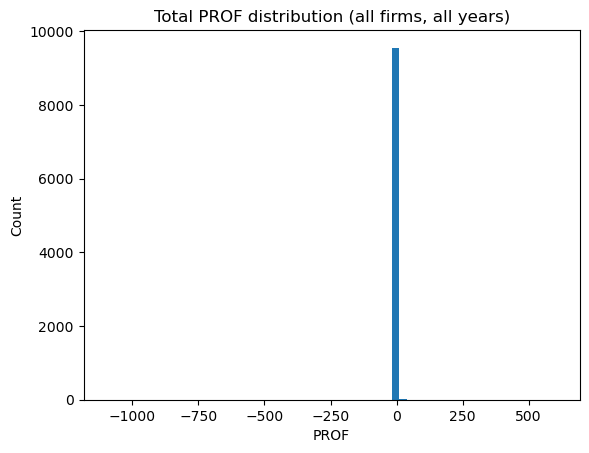

In [25]:
# Total distribution of PROF (all firms + all years currently in `panel`)
vals = pd.to_numeric(panel["PROF"], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()

plt.figure()
plt.hist(vals, bins=60)
plt.title("Total PROF distribution (all firms, all years)")
plt.xlabel("PROF")
plt.ylabel("Count")
plt.show()

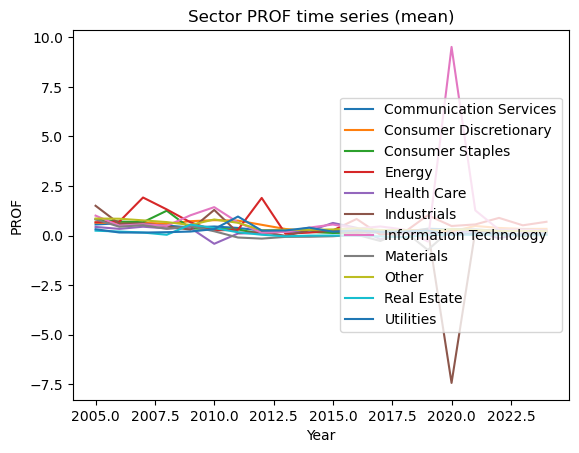

In [26]:
# Clean PROF
df = panel.copy()
df["PROF"] = pd.to_numeric(df["PROF"], errors="coerce").replace([np.inf, -np.inf], np.nan)

# Sector-year mean PROF (you can switch to median if you prefer)
ind_ts = (
    df.dropna(subset=["Sector", "PROF"])
      .groupby(["Year", "Sector"])["PROF"]
      .mean()
      .reset_index()
)

# Pivot to wide for plotting
wide = ind_ts.pivot(index="Year", columns="Sector", values="PROF").sort_index()

plt.figure()
for col in wide.columns:
    plt.plot(wide.index, wide[col], label=col)

plt.title("Sector PROF time series (mean)")
plt.xlabel("Year")
plt.ylabel("PROF")
plt.legend()
plt.show()

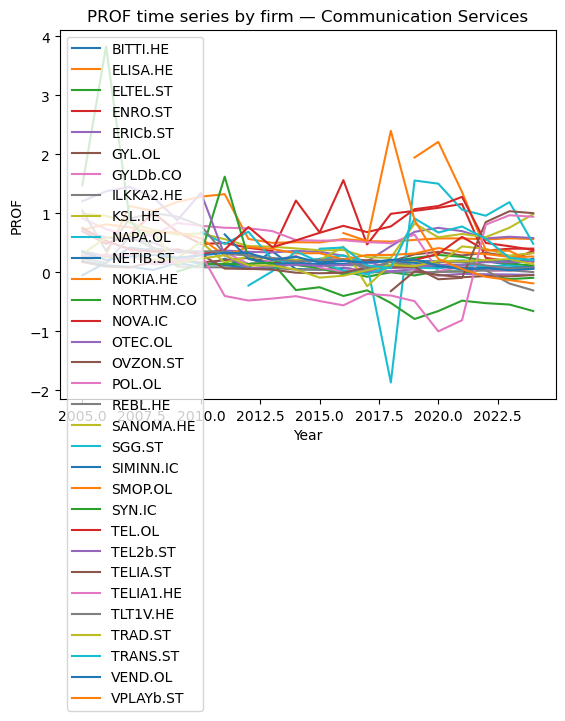

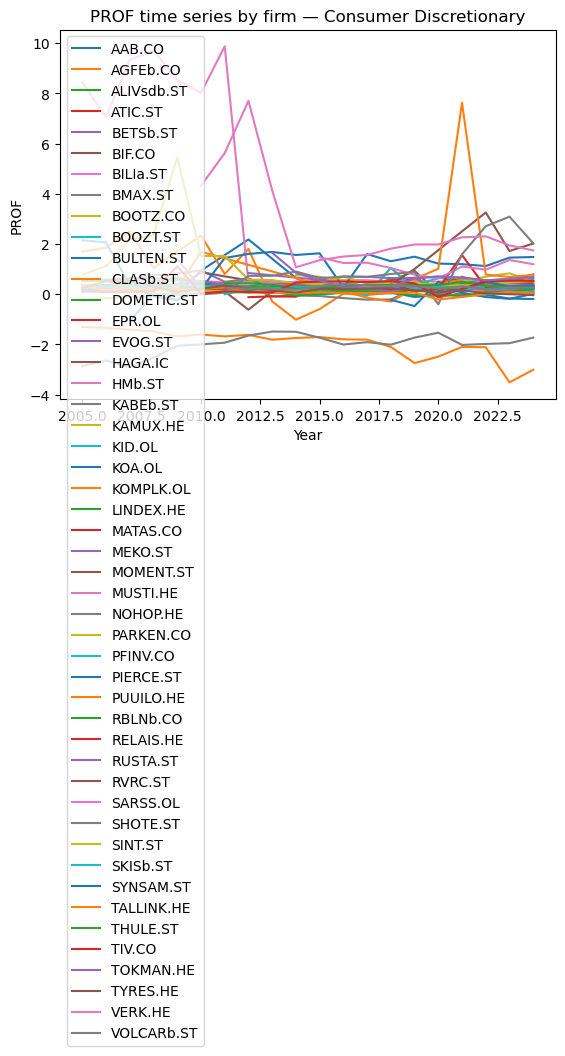

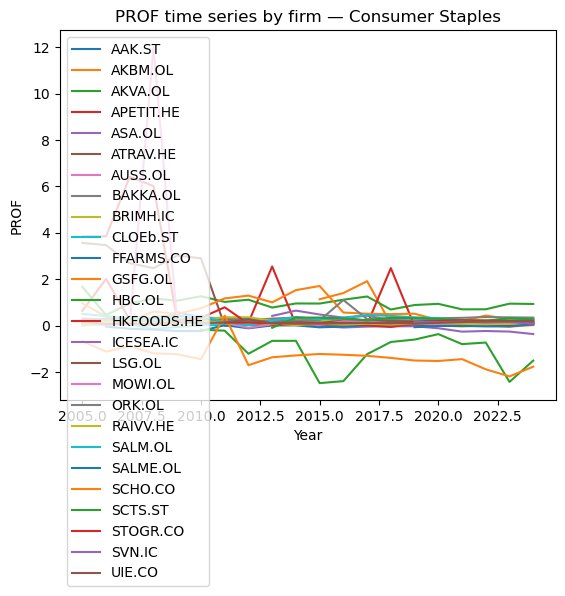

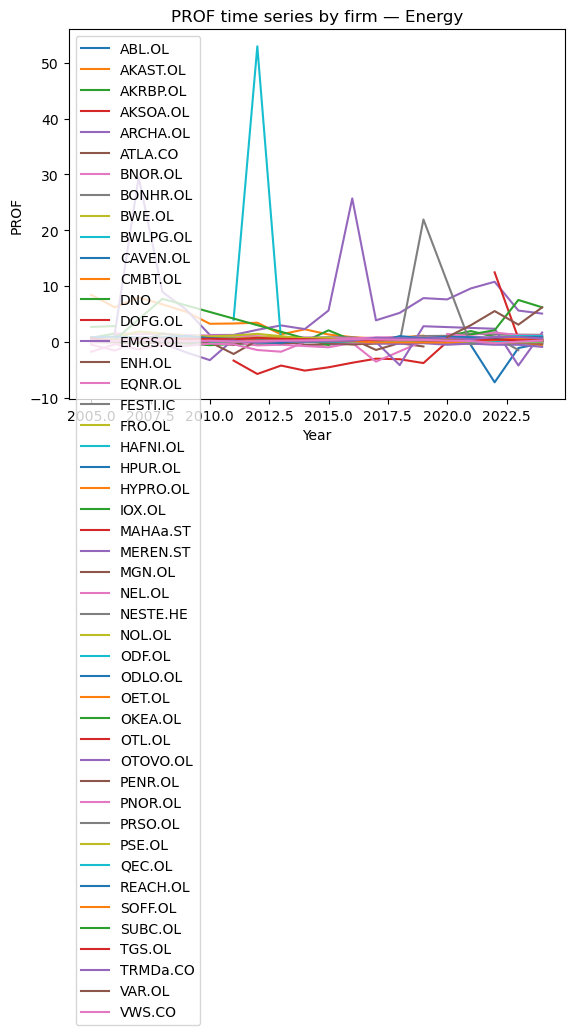

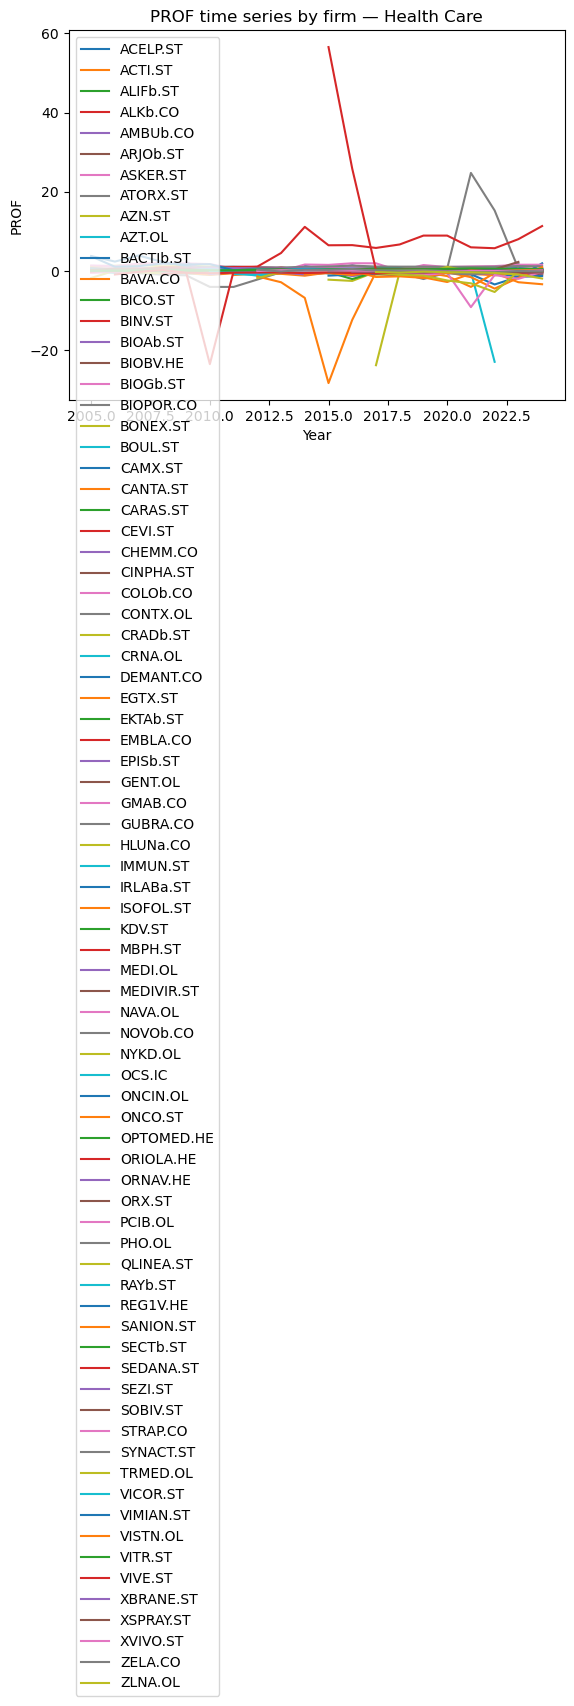

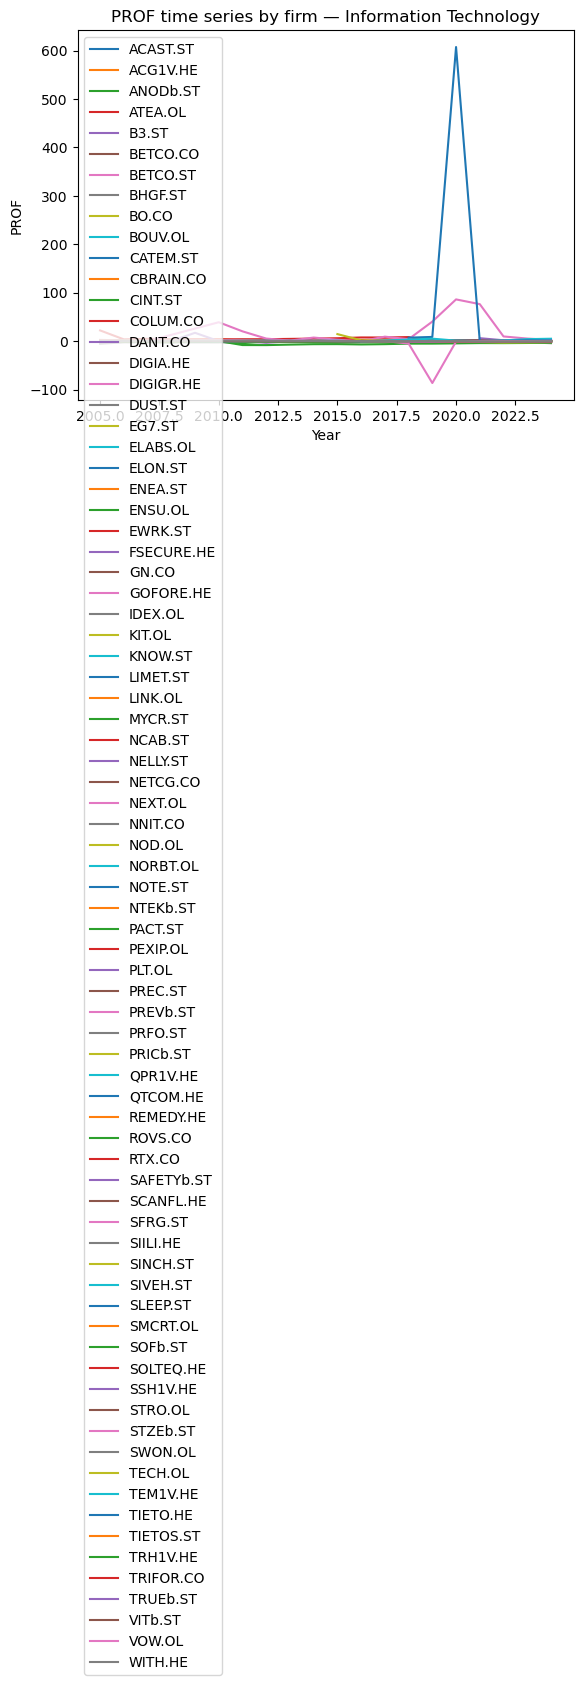

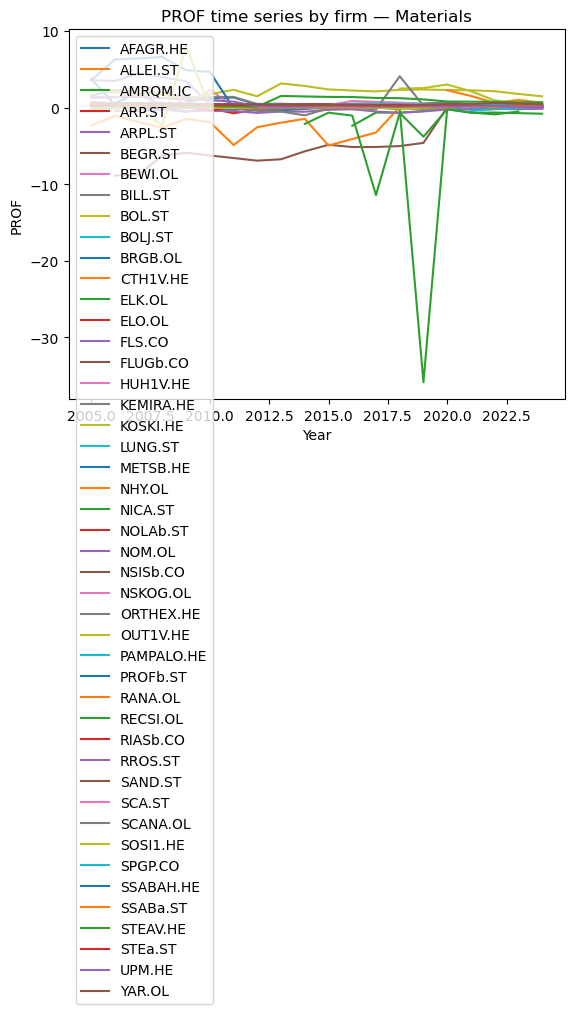

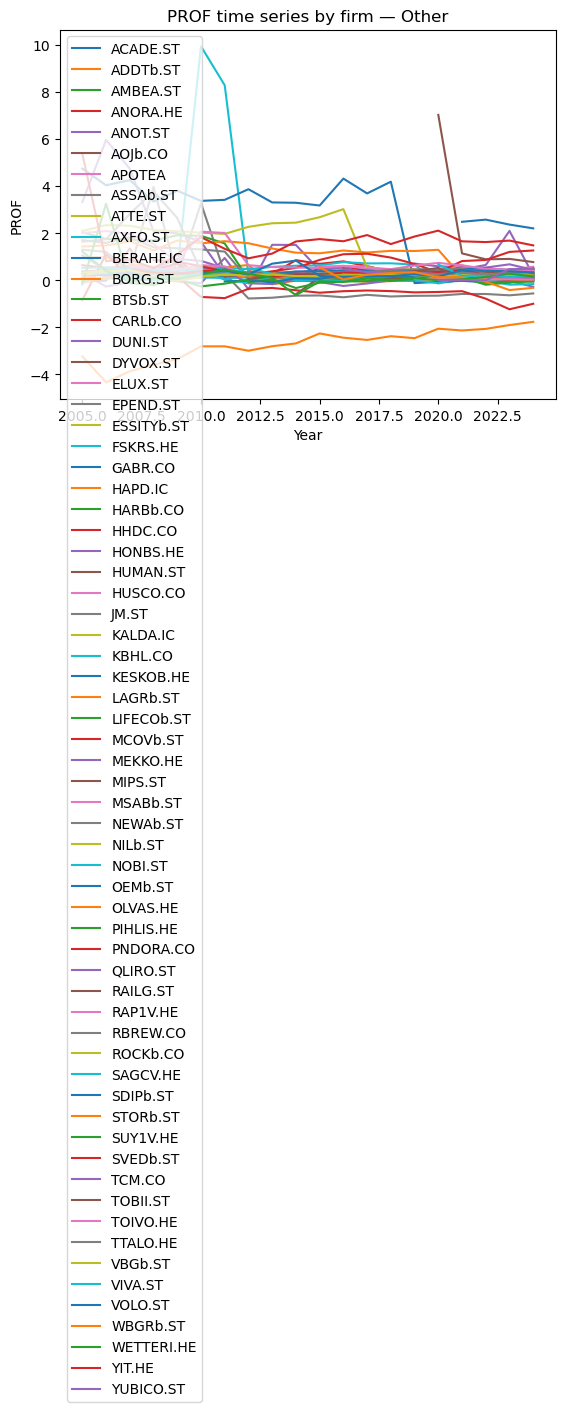

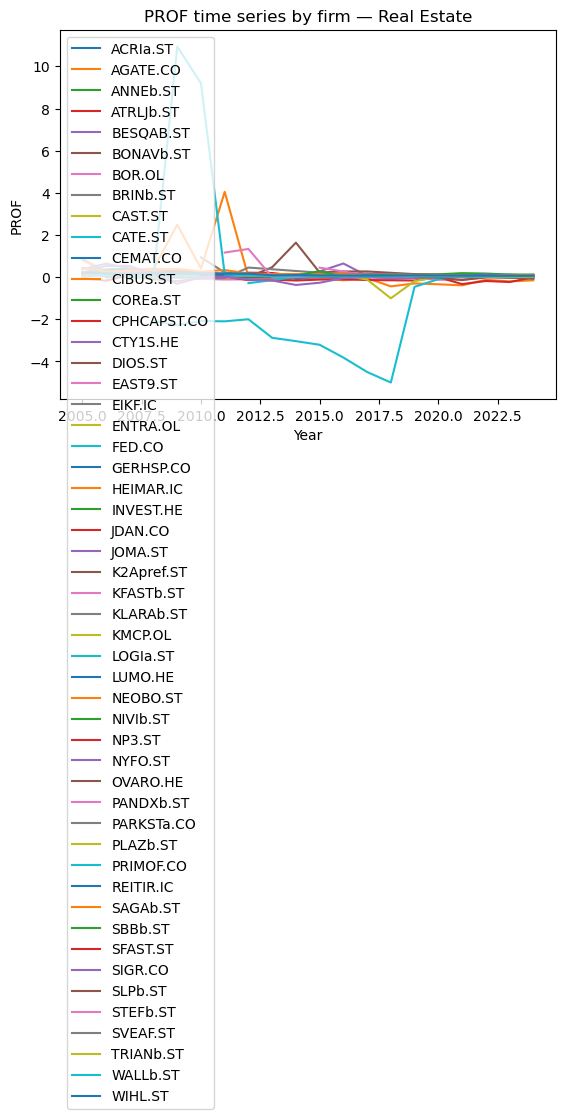

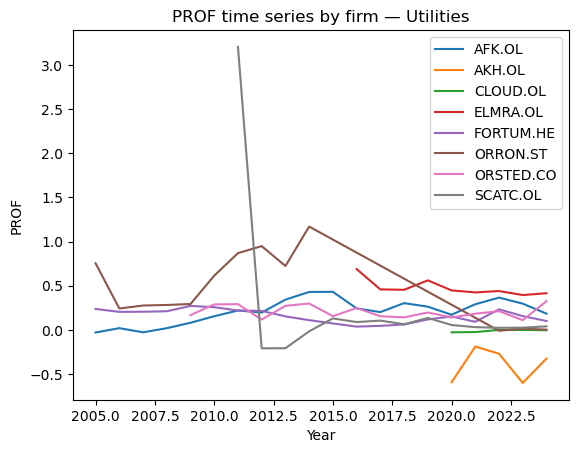

In [27]:
# Assumes `panel` exists and has columns: Year, firm, Industry, PROF
df = panel.copy()
df["PROF"] = pd.to_numeric(df["PROF"], errors="coerce").replace([np.inf, -np.inf], np.nan)

# Optional: pick a subset of industries to avoid insanely crowded plots
industries = sorted(df["Sector"].dropna().unique())

for ind in industries:
    sub = df[df["Sector"] == ind].dropna(subset=["PROF"]).copy()
    if sub.empty:
        continue

    plt.figure()
    for firm, g in sub.groupby("firm"):
        g = g.sort_values("Year")
        plt.plot(g["Year"], g["PROF"], label=firm)

    plt.title(f"PROF time series by firm — {ind}")
    plt.xlabel("Year")
    plt.ylabel("PROF")
    plt.legend()
    plt.show()

In [37]:
# All observations where |PROF| > 5 (using existing `panel`)
outliers = (
    panel.assign(PROF=pd.to_numeric(panel["PROF"], errors="coerce"))
         .replace([np.inf, -np.inf], np.nan)
         .dropna(subset=["PROF"])
)

outliers = outliers[outliers["PROF"].abs() > 10].copy()

# Show the key columns (add/remove as you like)
cols = [c for c in ["Year", "firm", "CompanyName", "Industry", "Sector", "PROF",
                    "REVT", "COGS", "XSGA_COMPONENTS", "XRD", "XINT", "BE", "MIB"] if c in outliers.columns]

outliers = outliers[cols].sort_values(["CompanyName", "Year"], ascending=[True, False]).reset_index(drop=True)

print(f"Found {len(outliers)} observations with |PROF| > 10")
display(outliers)

Found 42 observations with |PROF| > 10


,Year,firm,CompanyName,Industry,Sector,PROF,REVT,COGS,XSGA_COMPONENTS,XRD,XINT,BE,MIB
0,2010,AFG.OL,AF Gruppen ASA,Construction & Engineering,Industrials,86.681818,5828.00,3245.00,671.00,0.00,5.00,21.00,1.00
1,2005,AQ.ST,AQ Group AB,"Machinery, Tools, Heavy Vehicles, Trains & Ships",Industrials,48.867133,856.07,489.74,296.45,0.00,0.00,0.00,1.43
2,2022,ARCHA.OL,Archer Ltd,Oil & Gas Related Equipment and Services,Energy,10.768515,9321.13,0.00,391.02,0.00,332.42,798.41,0.00
3,2016,ARCHA.OL,Archer Ltd,Oil & Gas Related Equipment and Services,Energy,25.691739,7420.56,0.00,323.25,0.00,528.96,255.66,0.00
4,2007,ARCHA.OL,Archer Ltd,Oil & Gas Related Equipment and Services,Energy,29.511501,2728.10,0.00,0.00,0.00,33.70,86.90,4.40
5,2005,ATEA.OL,Atea ASA,Software & IT Services,Information Technology,22.455491,3091.40,0.00,1105.60,0.00,43.40,86.50,0.00
6,2012,BWLPG.OL,BW LPG Ltd,Oil & Gas Related Equipment and Services,Energy,52.939813,2197.19,895.14,0.00,0.00,0.26,-26.06,50.65
7,2022,CRNA.OL,Circio Holding ASA,Biotechnology & Medical Research,Health Care,-22.871595,10.00,0.00,110.92,47.23,5.09,2.57,0.00
8,2022,CONTX.OL,ContextVision AB,Healthcare Equipment & Supplies,Health Care,15.307407,111.95,2.28,68.15,0.00,0.19,2.70,0.00
9,2021,CONTX.OL,ContextVision AB,Healthcare Equipment & Supplies,Health Care,24.783251,98.32,1.97,45.94,0.00,0.10,2.03,0.00


In [ ]:
# Top 5 firms by average PROF over the last 5 years in `panel`
df = panel.copy()
df["PROF"] = pd.to_numeric(df["PROF"], errors="coerce").replace([np.inf, -np.inf], np.nan)

# Determine last 5 years available (based on panel years)
years = sorted(df["Year"].dropna().unique())
last5_years = years[-5:]

top5_last5 = (
    df[df["Year"].isin(last5_years)]
      .dropna(subset=["PROF"])
      .groupby("firm", as_index=False)
      .agg(avg_PROF=("PROF", "mean"),
           n_obs=("PROF", "count"),
           CompanyName=("CompanyName", "first"),
           Industry=("Industry", "first"),
           Sector=("Sector", "first"))
      .sort_values("avg_PROF", ascending=False)
      .head(5)
      .reset_index(drop=True)
)

print("Last 5 years used:", last5_years)
display(top5_last5)

Last 5 years used: [2020, 2021, 2022, 2023, 2024]


,firm,avg_PROF,n_obs,CompanyName,Industry,Sector
0,CONTX.OL,8.335314,5,ContextVision AB,Healthcare Equipment & Supplies,Health Care
1,MULTI.OL,4.004683,5,Multiconsult ASA,Construction & Engineering,Industrials
2,VAR.OL,3.753548,5,Var Energi ASA,Oil & Gas,Energy
3,TOM.OL,3.471495,5,Tomra Systems ASA,"Machinery, Tools, Heavy Vehicles, Trains & Ships",Industrials
4,HAVI.OL,3.105404,4,Havila Shipping ASA,Freight & Logistics Services,Industrials
